In [1]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request

import pandas as pd

In [2]:
import tensorflow as tf

2026-06-18 16:36:24.738339: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-18 16:36:24.789856: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-18 16:36:26.061543: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
import torch 
import torchvision

In [4]:
data = pd.read_csv("../solutions/galaxyquasar.csv")
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [5]:
cls = []
for c in data['class']:
    if c=='QSO': cls = np.append(cls, 1)
    elif c=='GALAXY': cls = np.append(cls, 0)

In [6]:
u_g = np.array(data['u']-data['g'])
g_r = np.array(data['g']-data['r'])
r_i = np.array(data['r']-data['i'])
i_z = np.array(data['i']-data['z'])
z = np.array(data['z1'])
zerr = np.array(data['zerr'])

In [7]:
from sklearn.naive_bayes import GaussianNB

X = np.array([u_g, g_r, r_i, i_z, z]).T
y = cls

gnb = GaussianNB()
gnb.fit(X,y)

y_pred = gnb.predict(X)
X.shape, y.shape

((50000, 5), (50000,))

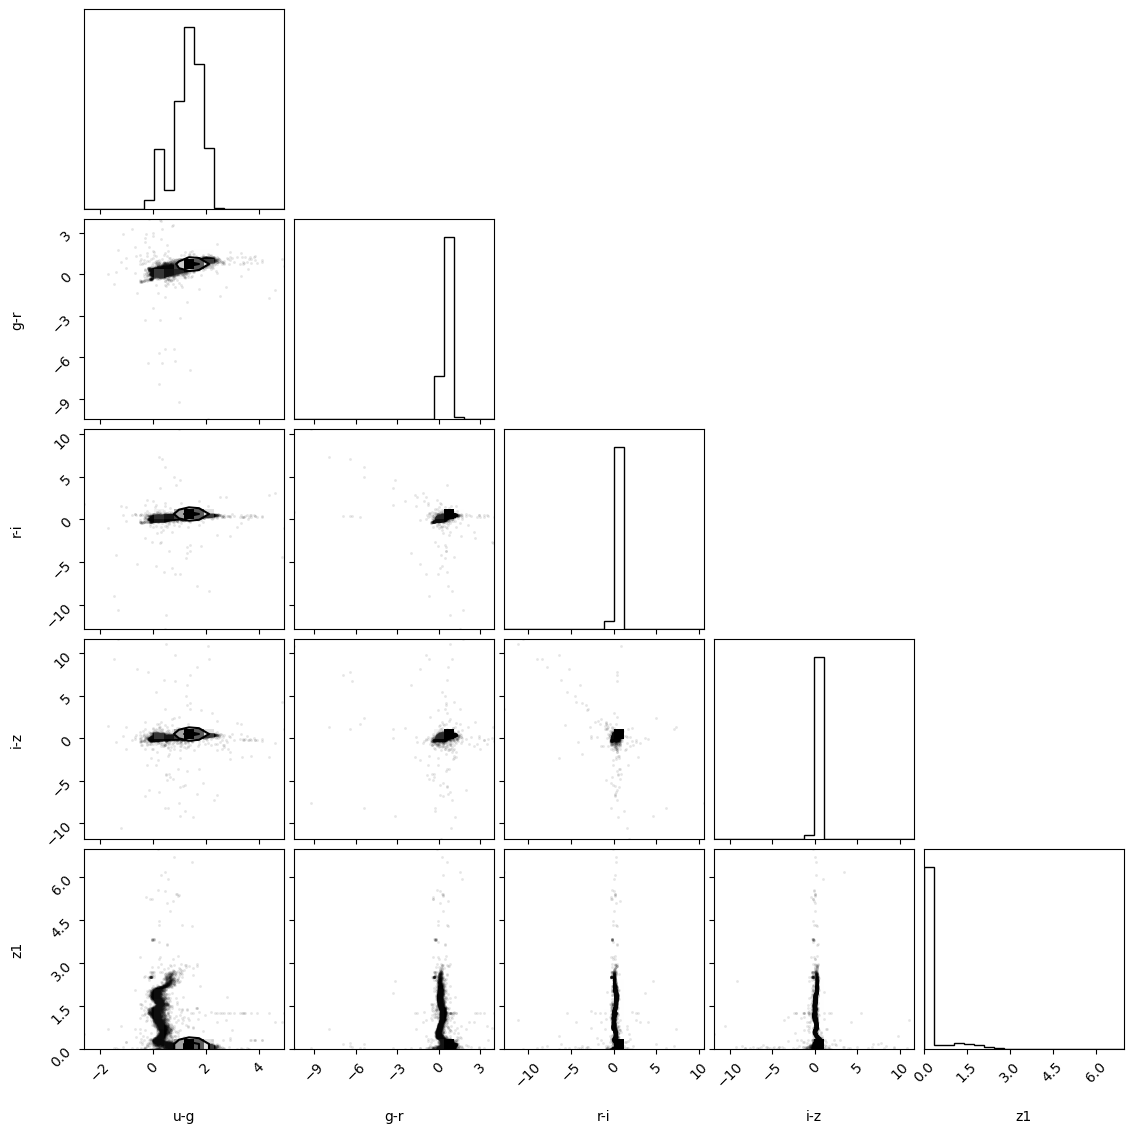

In [8]:
import corner
corner.corner(np.array([u_g,g_r,r_i,i_z,z]).T, labels=['u-g', 'g-r', 'r-i', 'i-z','z1']);

In [83]:
from sklearn.naive_bayes import GaussianNB
from astroML.utils import split_samples
from astroML.utils import completeness_contamination
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
Xs = sc.fit_transform(X)

(X_train_full, X_test_full), (y_train_full, y_test_full) = split_samples(Xs, y, [0.75, 0.25],
                                                     random_state=0)

X_train_full.shape, y_train_full.shape

((37500, 5), (37500,))

In [100]:
from tensorflow import keras


keras.backend.clear_session() # Make sure that we are starting a new model and not adding to an earlier one
np.random.seed(42) # Set the numpy and tensorflow random seeds so that we all get the same answer
tf.random.set_seed(42)



X_valid, X_train = X_train_full[:6000], X_train_full[6000:]
y_valid, y_train = y_train_full[:6000], y_train_full[6000:]
X_test = X_test_full 
y_test = y_test_full

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)


(31500, 5) (31500,)
(6000, 5) (6000,)
(12500, 5) (12500,)


In [101]:
X_train = X_train[:,:,np.newaxis]
X_valid = X_valid[:,:,np.newaxis]
X_test = X_test[:,:,np.newaxis]

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(31500, 5, 1) (31500,)
(6000, 5, 1) (6000,)
(12500, 5, 1) (12500,)


In [102]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=(5,1)),
    keras.layers.Conv1D(filters=64, kernel_size=7, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),  
    keras.layers.MaxPooling1D(pool_size=2),
    # keras.layers.Conv1D(256, 3, activation='relu', padding='same'),
    # keras.layers.Conv1D(256, 3, activation='relu', padding='same'),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=2, activation='softmax'),
])   

/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [103]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 5, 64)          │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,394 (388.26 KB)

 Trainable params: 99,394 (388.26 KB)

 Non-trainable params: 0 (0.00 B)

None


In [104]:
last_epoch = 20

model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=last_epoch, validation_data=(X_valid, y_valid))

Epoch 1/20
985/985 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9804 - loss: 0.1081 - val_accuracy: 0.9900 - val_loss: 0.0370
Epoch 2/20
985/985 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9898 - loss: 0.0422 - val_accuracy: 0.9893 - val_loss: 0.0361
Epoch 3/20
985/985 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9904 - loss: 0.0404 - val_accuracy: 0.9903 - val_loss: 0.0331
Epoch 4/20
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9901 - loss: 0.0416 - val_accuracy: 0.9893 - val_loss: 0.0339
Epoch 5/20
985/985 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9905 - loss: 0.0384 - val_accuracy: 0.9895 - val_loss: 0.0350
Epoch 6/20
985/985 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9913 - loss: 0.0358 - val_accuracy: 0.9902 - val_loss: 0.0344
Epoch 7/20
985/985 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9904 - loss: 0.0366 - val_accuracy: 0.9897 - val_loss: 0.0341
Epoch 8/20
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9910 - loss: 0.0375 - val_acc

In [105]:
X_new = X_test[:20]
y_proba = model.predict(X_new).round(4)
y_proba

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


array([[9.937e-01, 6.300e-03],
       [1.000e+00, 0.000e+00],
       [1.000e+00, 0.000e+00],
       [1.000e+00, 0.000e+00],
       [0.000e+00, 1.000e+00],
       [9.962e-01, 3.800e-03],
       [9.999e-01, 1.000e-04],
       [9.999e-01, 1.000e-04],
       [1.000e+00, 0.000e+00],
       [1.000e+00, 0.000e+00],
       [9.998e-01, 2.000e-04],
       [1.000e+00, 0.000e+00],
       [1.000e+00, 0.000e+00],
       [1.000e+00, 0.000e+00],
       [9.995e-01, 5.000e-04],
       [1.000e+00, 0.000e+00],
       [1.000e+00, 0.000e+00],
       [9.998e-01, 2.000e-04],
       [1.000e+00, 0.000e+00],
       [0.000e+00, 1.000e+00]], dtype=float32)

In [106]:
y_pred = np.argmax(model.predict(X_test), axis=-1)

391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [107]:
completeness, contamination = completeness_contamination(y_pred, y_test)

print("completeness", completeness)
print("contamination", contamination)

completeness 0.9733560090702947
contamination 0.021094640820980615


In [108]:
model

<Sequential name=sequential, built=True>

In [109]:
def predict_prob(number):
  return [number[0],1-number[0]]

y_prob = np.array(list(map(predict_prob, model.predict(X_test))))[:,1]
y_prob.shape 

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


(12500,)

In [110]:
fpr, tpr, thresh = roc_curve(y_test, y_prob)

(0.9, 1.0)

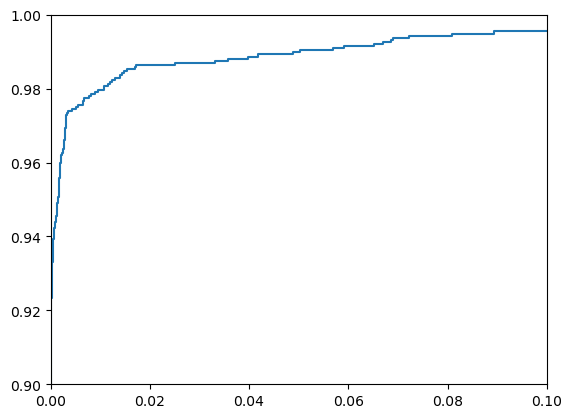

In [111]:
plt.plot(fpr,tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)

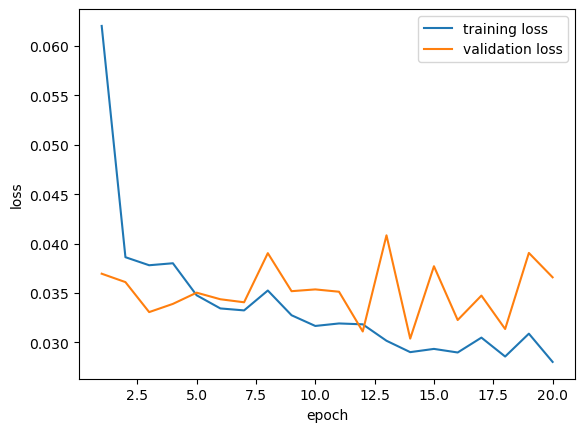

In [112]:
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['loss'], label='training loss')
plt.plot(epochs,clf.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')

plt.legend();

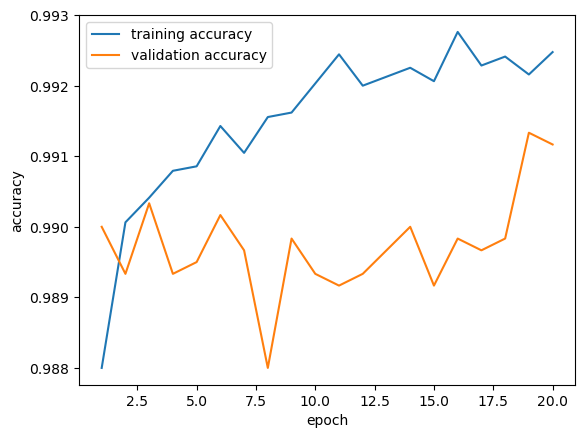

In [113]:
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['accuracy'], label='training accuracy')
plt.plot(epochs,clf.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')

plt.legend();

Epoch 1/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9903 - loss: 0.0491 - val_accuracy: 0.9895 - val_loss: 0.0397
Epoch 2/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9909 - loss: 0.0392 - val_accuracy: 0.9895 - val_loss: 0.0362
Epoch 3/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9912 - loss: 0.0381 - val_accuracy: 0.9903 - val_loss: 0.0371
Epoch 4/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9914 - loss: 0.0368 - val_accuracy: 0.9893 - val_loss: 0.0354
Epoch 5/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9910 - loss: 0.0376 - val_accuracy: 0.9905 - val_loss: 0.0335
Epoch 6/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9915 - loss: 0.0347 - val_accuracy: 0.9897 - val_loss: 0.0390
Epoch 7/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9915 - loss: 0.0366 - val_accuracy: 0.9897 - val_loss: 0.0361
Epoch 8/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9910 - loss: 0.0360 - val_acc

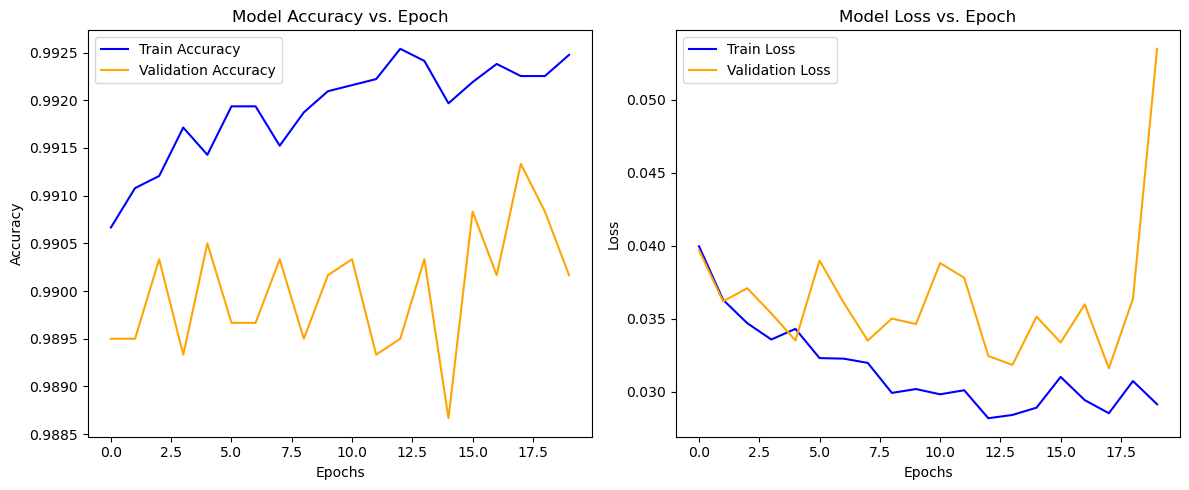

In [56]:
# model.compile(
#     optimizer='adam',
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# # 3. Fit the model and save the training metrics to a variable
# # Ensure validation_data or validation_split is defined to generate validation metrics
# history = model.fit(
#     X_train, y_train, 
#     epochs=20, 
#     batch_size=64, 
#     validation_data=(X_valid, y_valid)
# )

# # 4. Generate the Learning Curve Plots
# # Plot 1: Classification Accuracy Curve
# plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 1)
# plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
# plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
# plt.title('Model Accuracy vs. Epoch')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.legend()

# # Plot 2: Loss Function Curve
# plt.subplot(1, 2, 2)
# plt.plot(history.history['loss'], label='Train Loss', color='blue')
# plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
# plt.title('Model Loss vs. Epoch')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.legend()

# plt.tight_layout()
# plt.show()

In [62]:
np.argmin(history.history['val_loss'])

17